# Customer Segmentation using K-Means Clustering

### Objective
The objective of this project is to segment customers based on their purchasing behavior using the K-Means Clustering algorithm. Customer segmentation helps businesses identify different customer groups for targeted marketing and better decision-making.

## Import Required Libraries

Import all the necessary libraries for data analysis, visualization, preprocessing, and machine learning.

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

plt.style.use("ggplot")

## Load and Explore the Dataset

Load the dataset and understand its structure, dimensions, data types, and missing values.

In [18]:
df = pd.read_csv("online_retail.csv")

##  Data Cleaning

Clean the dataset by removing missing values, cancelled transactions, and invalid records to improve data quality.

In [19]:
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [20]:
df.shape

(541909, 9)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        541909 non-null  int64  
 1   InvoiceNo    541909 non-null  object 
 2   StockCode    541909 non-null  object 
 3   Description  540455 non-null  object 
 4   Quantity     541909 non-null  int64  
 5   InvoiceDate  541909 non-null  object 
 6   UnitPrice    541909 non-null  float64
 7   CustomerID   406829 non-null  float64
 8   Country      541909 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 37.2+ MB


In [22]:
df.describe()

,index,Quantity,UnitPrice,CustomerID
count,541909.00000,541909.000000,541909.000000,406829.000000
mean,270954.00000,9.552250,4.611114,15287.690570
std,156435.79785,218.081158,96.759853,1713.600303
min,0.00000,-80995.000000,-11062.060000,12346.000000
25%,135477.00000,1.000000,1.250000,13953.000000
50%,270954.00000,3.000000,2.080000,15152.000000
75%,406431.00000,10.000000,4.130000,16791.000000
max,541908.00000,80995.000000,38970.000000,18287.000000


In [23]:
df.isnull().sum()

,0
index,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [24]:
df = df.dropna(subset=["CustomerID"])

In [25]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [26]:
df = df[df["Quantity"] > 0]

In [27]:
df = df[df["UnitPrice"] > 0]

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        397884 non-null  int64  
 1   InvoiceNo    397884 non-null  object 
 2   StockCode    397884 non-null  object 
 3   Description  397884 non-null  object 
 4   Quantity     397884 non-null  int64  
 5   InvoiceDate  397884 non-null  object 
 6   UnitPrice    397884 non-null  float64
 7   CustomerID   397884 non-null  float64
 8   Country      397884 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 30.4+ MB


In [29]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [30]:
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [31]:
print(df["TotalAmount"].mean())

22.396999889415003


In [32]:
print(df["Quantity"].mean())

12.988237777844798


In [33]:
print(df["TotalAmount"].sum())

8911407.904


In [34]:
print(df["CustomerID"].nunique())

4338


RFM Analysis

In [35]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [36]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [37]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

In [38]:
rfm.columns = ["Recency","Frequency","Monetary"]

In [39]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [40]:
rfm["CLV"] = rfm["Monetary"]

In [41]:
rfm["CLV"].mean()

np.float64(2054.2664601198708)

In [42]:
features = rfm[["Recency","Frequency","Monetary"]]

Standardize Data

In [43]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

Elbow Method

In [44]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

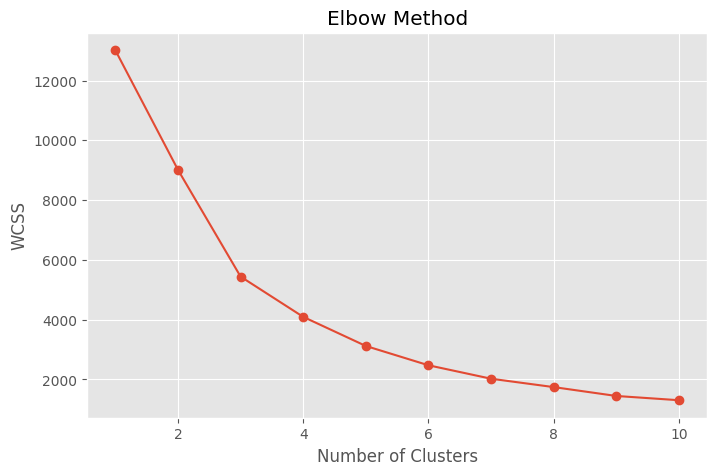

In [45]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

Applying K-Means

In [46]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(scaled_features)

In [47]:
rfm.head()

,Recency,Frequency,Monetary,CLV,Cluster
CustomerID,,,,,
12346.0,326,1,77183.60,77183.60,3
12347.0,2,7,4310.00,4310.00,0
12348.0,75,4,1797.24,1797.24,0
12349.0,19,1,1757.55,1757.55,0
12350.0,310,1,334.40,334.40,1


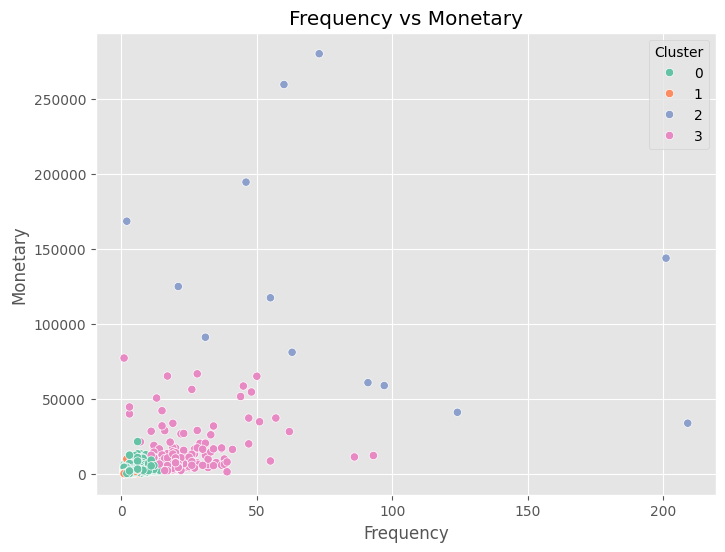

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Frequency vs Monetary")

plt.show()

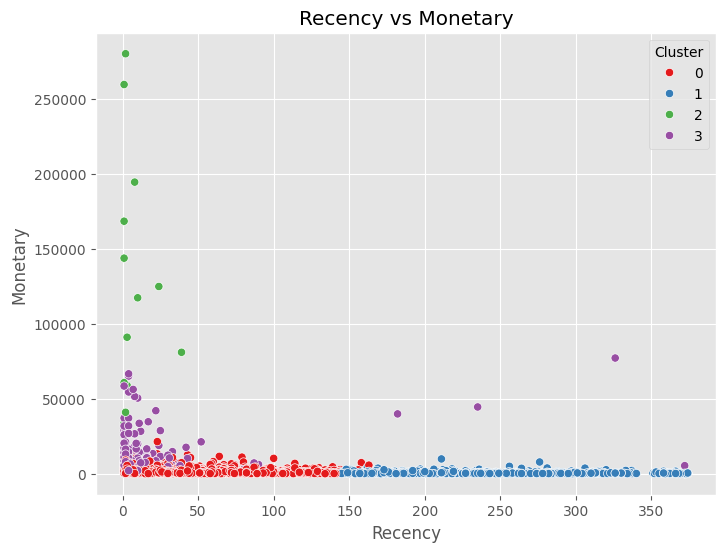

In [49]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set1"
)

plt.title("Recency vs Monetary")

plt.show()

In [50]:
cluster_profile = rfm.groupby("Cluster").mean()

cluster_profile

,Recency,Frequency,Monetary,CLV
Cluster,,,,
0,43.702685,3.682711,1359.049284,1359.049284
1,248.075914,1.552015,480.617480,480.617480
2,7.384615,82.538462,127338.313846,127338.313846
3,15.500000,22.333333,12709.090490,12709.090490


In [51]:
cluster_profile.round(2)

,Recency,Frequency,Monetary,CLV
Cluster,,,,
0,43.70,3.68,1359.05,1359.05
1,248.08,1.55,480.62,480.62
2,7.38,82.54,127338.31,127338.31
3,15.50,22.33,12709.09,12709.09


Customer Count

In [52]:
rfm["Cluster"].value_counts()

,count
Cluster,
0,3054
1,1067
3,204
2,13


/tmp/ipykernel_610/1994281309.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


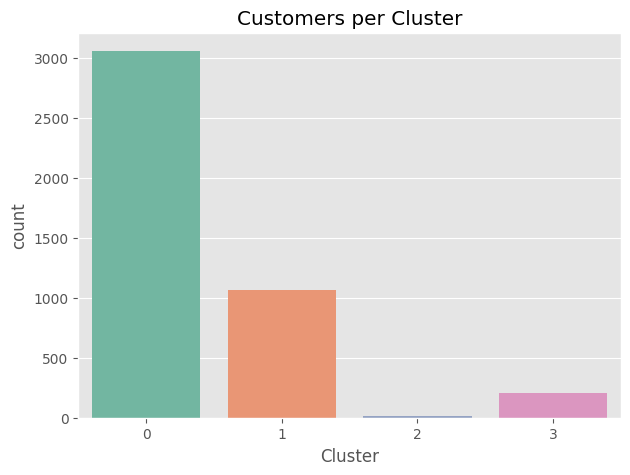

In [53]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Cluster",
    data=rfm,
    palette="Set2"
)

plt.title("Customers per Cluster")

plt.show()

## Conclusion

This project successfully segmented customers using RFM Analysis and K-Means clustering. The identified customer groups can help businesses improve marketing strategies, customer retention, and overall profitability through targeted campaigns.